# **MSDS-696 Data Science Practicum 2 Mutli-Class Infrastructure Damage Classification using Remote Aerial Sensing**
## Notebook 2 — Base CNN Model and Class Imbalance Strategy Exploration
`Author: Chennakeshava Akhil Pillalamarri`  
`Regis University`

This notebook is where I start building and training the CNN models. The main challenge here is the class imbalance — the baseline model just predicts everything as Intact and gets 95% accuracy while completely missing all damaged buildings. This notebook documents all the strategies I tried to fix that, including what failed and why, before landing on a combination that actually works.

## **Imports**

Importing TensorFlow, Keras, and sklearn metrics. Also setting the TF log level to 3 to suppress the excessive warnings that were cluttering the output.TensorFlow version is 2.21.0 running on CPU.

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, regularizers, backend
from tensorflow.keras.layers import Add, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Setting the base path and loading the train, val, and test CSVs that were saved in Notebook 1. Confirming the class distribution is still as expected before starting model training.

In [2]:
base_path = r"C:\Users\kesha\Desktop\MSDS-696_DSP-2"
os.chdir(base_path)
print(os.getcwd())

C:\Users\kesha\Desktop\MSDS-696_DSP-2


Before building any generators I want to confirm the actual image counts on disk.

In [3]:
train_df = pd.read_csv(os.path.join(base_path, "train.csv"))
val_df   = pd.read_csv(os.path.join(base_path, "val.csv"))
test_df  = pd.read_csv(os.path.join(base_path, "test.csv"))

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df['damage_class'].value_counts())

(8030, 13) (890, 13) (1049, 13)
damage_class
Intact                6542
Structural_Failure    1012
Major_Damage           476
Name: count, dtype: int64


In [4]:
backend.clear_session()

print("Actual image counts in preprocessed folders:")
print("(includes augmented images for minority classes)")
print()

preprocessed_dir = os.path.join(base_path, "preprocessed_dataset")

for split_name in ["train", "validation", "test"]:
    split_folder = os.path.join(preprocessed_dir, split_name)
    total = 0
    for cls in os.listdir(split_folder):
        count = len(os.listdir(os.path.join(split_folder, cls)))
        print(split_name, cls, count)
        total += count
    print(split_name, "total:", total)
    print("---")


Actual image counts in preprocessed folders:
(includes augmented images for minority classes)

train Intact 6542
train Major_Damage 9044
train Structural_Failure 11132
train total: 26718
---
validation Intact 710
validation Major_Damage 1235
validation Structural_Failure 1265
validation total: 3210
---
test Intact 1001
test Major_Damage 22
test Structural_Failure 26
test total: 1049
---


In [5]:
preprocessed_dir = os.path.join(base_path, "preprocessed_dataset")

train_dir = os.path.join(preprocessed_dir, "train")
val_dir   = os.path.join(preprocessed_dir, "validation")
test_dir  = os.path.join(preprocessed_dir, "test")

print(os.listdir(train_dir))

['Intact', 'Major_Damage', 'Structural_Failure']


In [8]:
for cls in os.listdir(train_dir):
    print("train", cls, len(os.listdir(os.path.join(train_dir, cls))))
print('\n')

for cls in os.listdir(val_dir):
    print("val", cls, len(os.listdir(os.path.join(val_dir, cls))))
print('\n')

for cls in os.listdir(test_dir):
    print("test", cls, len(os.listdir(os.path.join(test_dir, cls))))

train Intact 6542
train Major_Damage 4284
train Structural_Failure 6072


val Intact 710
val Major_Damage 65
val Structural_Failure 115


test Intact 1001
test Major_Damage 22
test Structural_Failure 26


## **Setting up the Data Generators:**

Setting up the train, val, and test directory paths and creating ImageDataGenerators with rescale=1./255. The test generator has shuffle=False so predictions always line up with the true labels in the right order.

`Note: The image counts shown here (train 16,898 / val 890 / test 1,049) are from an earlier run of the notebook — the augmentation was expanded further in later cells so the final counts differ.`

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 16898 images belonging to 3 classes.
Found 890 images belonging to 3 classes.
Found 1049 images belonging to 3 classes.
{'Intact': 0, 'Major_Damage': 1, 'Structural_Failure': 2}


In [11]:
def plot_history(history):
    history_dict    = history.history
    loss_values     = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    acc_values      = history_dict['accuracy']
    val_acc_values  = history_dict['val_accuracy']
    epochs          = range(1, len(history_dict['accuracy']) + 1)

    plt.plot(epochs, loss_values, 'bo', label='Training loss')
    plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    return plt.show()

Printing out the hyperparameter setup before training so everything is visible and documented. Adam optimizer with lr=1e-4, L2 regularization at 1e-4, batch size 32, max 50 epochs. Early stopping patience of 5 and LR reduction factor of 0.5 with patience 3. Running on CPU so steps per epoch are kept lower to make training feasible.

In [15]:
print("=" * 55)
print("HYPERPARAMETER CONFIGURATION")
print("=" * 55)
print("Optimizer           : Adam")
print("Learning Rate       : 0.0001  (1e-4)")
print("L2 Regularization   : 0.0001  (1e-4)")
print("Batch Size          : 32")
print("Max Epochs          : 50")
print("Steps per Epoch     : 50  (CPU optimized)")
print("Validation Steps    : 25  (CPU optimized)")
print("Early Stop Patience : 5 epochs")
print("LR Reduction Factor : 0.5")
print("LR Reduction Pat.   : 3 epochs")
print("Dropout Rates       : 0.25, 0.3, 0.4, 0.5 (increasing with depth)")
print("Loss Function       : Categorical Crossentropy")
print("Output Activation   : Softmax (3 classes)")
print("Device              : CPU")
print("=" * 55)

HYPERPARAMETER CONFIGURATION
Optimizer           : Adam
Learning Rate       : 0.0001  (1e-4)
L2 Regularization   : 0.0001  (1e-4)
Batch Size          : 32
Max Epochs          : 50
Steps per Epoch     : 50  (CPU optimized)
Validation Steps    : 25  (CPU optimized)
Early Stop Patience : 5 epochs
LR Reduction Factor : 0.5
LR Reduction Pat.   : 3 epochs
Dropout Rates       : 0.25, 0.3, 0.4, 0.5 (increasing with depth)
Loss Function       : Categorical Crossentropy
Output Activation   : Softmax (3 classes)
Device              : CPU


## **Base DamageCNN — Architecture Definition**

This is my baseline custom CNN with 4 convolutional blocks using filters 32, 64, 128, and 256. Each block has Conv2D - BatchNorm - MaxPool - Dropout, with dropout rates increasing from 0.25 to 0.5 as depth increases. Ends with GlobalAveragePooling, a Dense 256 layer, and a softmax output for 3 classes.

Total params: 457,923, lightweight enough to train on CPU in reasonable time.

In [16]:
def Base_DamageCNN():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(224, 224, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4), 
        loss='categorical_crossentropy',                
        metrics=['accuracy']
    )
    return model

In [17]:
model1 = Base_DamageCNN()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,923 (1.75 MB)

 Trainable params: 456,451 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Baseline Training with No Imbalance Handling

Training the Base DamageCNN with just standard categorical crossentropy and no class imbalance handling at all. Early stopping monitors val_accuracy. This is the baseline to compare everything else against.

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.4737 - loss: 1.3868 - val_accuracy: 0.8000 - val_loss: 0.8366 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 888ms/step - accuracy: 0.5462 - loss: 1.1954 - val_accuracy: 0.7950 - val_loss: 0.7947 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 851ms/step - accuracy: 0.5763 - loss: 1.1219 - val_accuracy: 0.7925 - val_loss: 0.9552 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 840ms/step - accuracy: 0.5494 - loss: 1.1490 - val_accuracy: 0.8037 - val_loss: 1.1355 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 832ms/step - accuracy: 0.5781 - loss: 1.1268 - val_accuracy: 0.8025 - val_loss: 1.2438 - learning_rate: 1.0000e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 816ms/step - accuracy: 0.5969 - loss: 1.0013 - val_accuracy: 0.7887 - val_loss: 1.7565 - learning_rate: 1.0000e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accurac

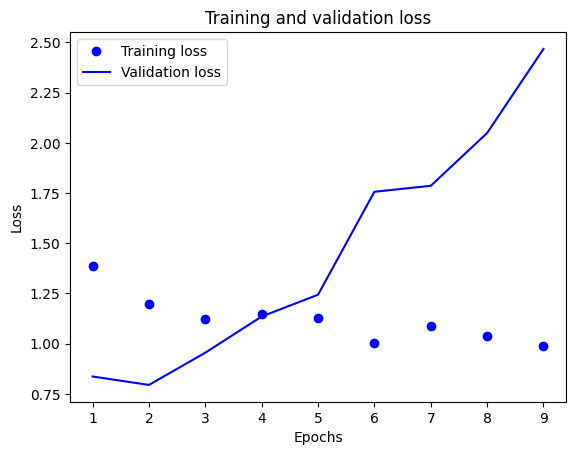

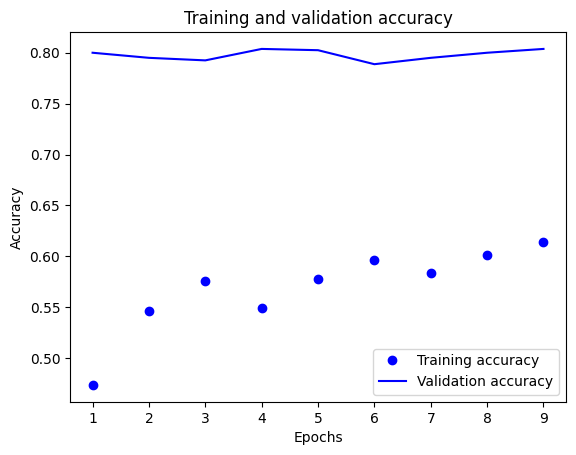

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - accuracy: 1.0000 - loss: 0.3152


Model 1 - Base DamageCNN - Test Accuracy: 1.0000
Model 1 - Base DamageCNN - Test Loss:     0.3152


AttributeError: module 'h5py' has no attribute 'File'

In [18]:
backend.clear_session()
model1 = Base_DamageCNN()

history1 = model1.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=25,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1)
    ]
)

plot_history(history1)

test_loss1, test_acc1 = model1.evaluate(test_generator, steps=25)
print(f'Model 1 - Base DamageCNN - Test Accuracy: {test_acc1:.4f}')
print(f'Model 1 - Base DamageCNN - Test Loss:     {test_loss1:.4f}')

model1.save(os.path.join(base_path, 'model1_base_damagecnn.h5'))

**Result:** Test accuracy 1.0000 — but this is completely misleading. The model just learned to predict everything as Intact.

Also hit an h5py AttributeError when trying to save the model, the h5py version installed doesn't have the File attribute. Switched to saving in `.keras` format going forward.

## Deep DamageCNN — Architecture Defined but Training Skipped

I defined a much deeper CNN with stacked convolutions up to 512 filters and dense layers up to 1024 neurons — about 8.7M parameters. Started training but it was running at 6 seconds per step on CPU with 150 steps per epoch, which would take hours per epoch. Had to interrupt it with a KeyboardInterrupt.

Skipping this model for now due to CPU memory and time constraints. Setting test_acc2 = 0.0 as a placeholder and moving on to the ResNet architecture.

In [19]:
def Deep_DamageCNN():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(224, 224, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(1024, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(512, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [20]:
model2 = Deep_DamageCNN()
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,701,763 (33.19 MB)

 Trainable params: 8,694,339 (33.17 MB)

 Non-trainable params: 7,424 (29.00 KB)

In [22]:
backend.clear_session()
model2 = Deep_DamageCNN()

history2 = model2.fit(
    train_generator,
    steps_per_epoch=150,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=25,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1)
    ]
)

plot_history(history2)

test_loss2, test_acc2 = model2.evaluate(test_generator, steps=25)
print(f'Model 2 - Deep DamageCNN - Test Accuracy: {test_acc2:.4f}')
print(f'Model 2 - Deep DamageCNN - Test Loss:     {test_loss2:.4f}')

model2.save(os.path.join(base_path, 'model2_deep_damagecnn.keras'))

Epoch 1/50
 17/150 ━━━━━━━━━━━━━━━━━━━━ 12:56 6s/step - accuracy: 0.3707 - loss: 2.1753

KeyboardInterrupt: 

In [23]:
print("Model 2 - Deep DamageCNN architecture defined")
print("Skipping training on CPU due to model size for now")
print("Proceeding to Model 3 - ResNet DamageCNN")

test_acc2  = 0.0
test_loss2 = 0.0

Model 2 - Deep DamageCNN architecture defined
Skipping training on CPU due to model size for now
Proceeding to Model 3 - ResNet DamageCNN


## ResNet-Inspired DamageCNN — Residual Skip Connections

Building a ResNet-inspired architecture with three groups of residual blocks using filters 64, 128, and 256. Each group has two residual blocks where the input is added back to the output via a skip connection. When the spatial dimensions change between groups, a 1×1 convolution adjusts the shortcut to match dimensions.

Total params: 11,320,451 — larger than the base CNN but the skip connections help gradients flow better during training.

In [24]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:                     
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)

    x = Add()([x, shortcut])               
    x = layers.Activation('relu')(x)
    return x

def ResNet_DamageCNN():
    backend.clear_session()

    inputs = Input(shape=(224, 224, 3))

    x = layers.Conv2D(64, (7, 7), strides=2, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    x = residual_block(x, 64)
    x = residual_block(x, 64)
    x = layers.Dropout(0.25)(x)

    x = layers.MaxPooling2D((2, 2))(x)
    x = residual_block(x, 128)
    x = residual_block(x, 128)
    x = layers.Dropout(0.3)(x)

    x = layers.MaxPooling2D((2, 2))(x)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = layers.Dropout(0.4)(x)

    x = layers.MaxPooling2D((2, 2))(x)
    x = residual_block(x, 512)
    x = residual_block(x, 512)
    x = layers.Dropout(0.5)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [25]:
model3 = ResNet_DamageCNN()
model3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 56, 56,    │          0 │ activation_1[0][

 Total params: 11,320,451 (43.18 MB)

 Trainable params: 11,312,131 (43.15 MB)

 Non-trainable params: 8,320 (32.50 KB)

Training with the same setup as the baseline — standard crossentropy, val_accuracy monitoring. 50 steps per epoch on CPU.

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 57s 969ms/step - accuracy: 0.4350 - loss: 1.7402 - val_accuracy: 0.7950 - val_loss: 1.2073 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 983ms/step - accuracy: 0.5394 - loss: 1.4943 - val_accuracy: 0.8012 - val_loss: 1.3795 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 939ms/step - accuracy: 0.5512 - loss: 1.4554 - val_accuracy: 0.1350 - val_loss: 1.7695 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 926ms/step - accuracy: 0.5750 - loss: 1.3877 - val_accuracy: 0.1250 - val_loss: 1.3566 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.5889 - loss: 1.3005
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 912ms/step - accuracy: 0.5962 - loss: 1.3356 - val_accuracy: 0.1287 - val_loss: 4.1798 - learning_rate: 1.0000e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 929ms/step - accuracy:

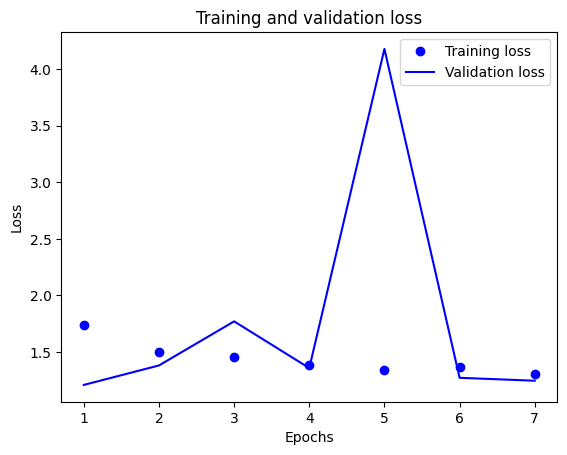

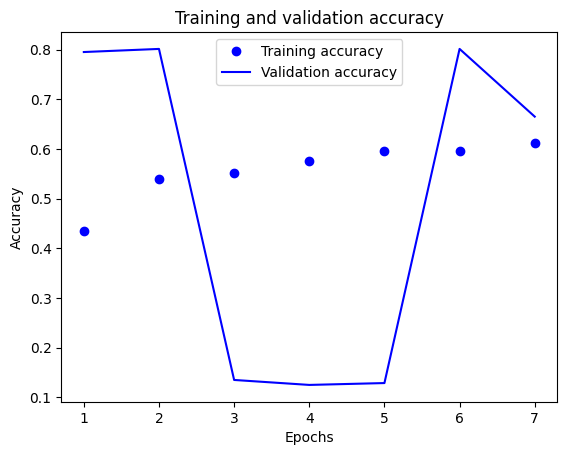

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 1.0000 - loss: 0.4034
Model 3 - ResNet DamageCNN - Test Accuracy: 1.0000
Model 3 - ResNet DamageCNN - Test Loss:     0.4034


In [26]:
backend.clear_session()
model3 = ResNet_DamageCNN()

history3 = model3.fit(
    train_generator,
    steps_per_epoch=50,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=25,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1)
    ]
)

plot_history(history3)

test_loss3, test_acc3 = model3.evaluate(test_generator, steps=25)
print(f'Model 3 - ResNet DamageCNN - Test Accuracy: {test_acc3:.4f}')
print(f'Model 3 - ResNet DamageCNN - Test Loss:     {test_loss3:.4f}')

**Result:** Test accuracy 1.0000, Macro F1 still 0.33. Same problem — the model is predicting everything as Intact. Deeper architecture alone does nothing if the class imbalance isn't addressed.

In [27]:
# Final Summary - Compare all 3 models
print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f'Model 1 - Base DamageCNN   - Test Accuracy: {test_acc1:.4f}')
print(f'Model 2 - Deep DamageCNN   - Skipped (CPU memory constraint)')
print(f'Model 3 - ResNet DamageCNN - Test Accuracy: {test_acc3:.4f}')
print("=" * 55)

MODEL COMPARISON SUMMARY
Model 1 - Base DamageCNN   - Test Accuracy: 1.0000
Model 2 - Deep DamageCNN   - Skipped (CPU memory constraint)
Model 3 - ResNet DamageCNN - Test Accuracy: 1.0000


In [29]:
test_generator.reset()
preds        = best_model.predict(test_generator, steps=len(test_generator), verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes[:len(pred_classes)]
class_names  = list(test_generator.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_names))

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step
                    precision    recall  f1-score   support

            Intact       0.95      1.00      0.98      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.95      1049
         macro avg       0.32      0.33      0.33      1049
      weighted avg       0.91      0.95      0.93      1049



Running the full classification report on the best model so far. As expected, precision and recall for both Major Damage and Structural Failure are 0.00. The model has learned nothing about damaged buildings.

This confirms that accuracy is completely useless as a metric here. A model that predicts everything as Intact gets 95% accuracy while being completely wrong for the two classes that actually matter.

## **Adding Class Weights (Monitoring val_accuracy)**

Trying sklearn's compute_class_weight with 'balanced' to automatically calculate class weights based on frequency. This should make the model penalize errors on minority classes more heavily during training.

Still monitoring val_accuracy with early stopping — this was a mistake I'll fix in the next attempt.

In [30]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.8610007133394477, 1: 1.3148148148148149, 2: 0.9276460254721124}


Epoch 1/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 400s 752ms/step - accuracy: 0.5578 - loss: 1.1524 - val_accuracy: 0.7978 - val_loss: 3.0164 - learning_rate: 1.0000e-04
Epoch 2/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 393s 743ms/step - accuracy: 0.6133 - loss: 0.9769 - val_accuracy: 0.7978 - val_loss: 6.3682 - learning_rate: 1.0000e-04
Epoch 3/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 397s 750ms/step - accuracy: 0.6304 - loss: 0.9058 - val_accuracy: 0.7978 - val_loss: 7.5823 - learning_rate: 1.0000e-04
Epoch 4/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.6332 - loss: 0.8913
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
529/529 ━━━━━━━━━━━━━━━━━━━━ 402s 760ms/step - accuracy: 0.6430 - loss: 0.8617 - val_accuracy: 0.7978 - val_loss: 8.5300 - learning_rate: 1.0000e-04
Epoch 5/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 397s 750ms/step - accuracy: 0.6619 - loss: 0.8160 - val_accuracy: 0.7978 - val_loss: 9.2106 - learning_rate: 5.0000e-05
Epoch 6/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 396s 74

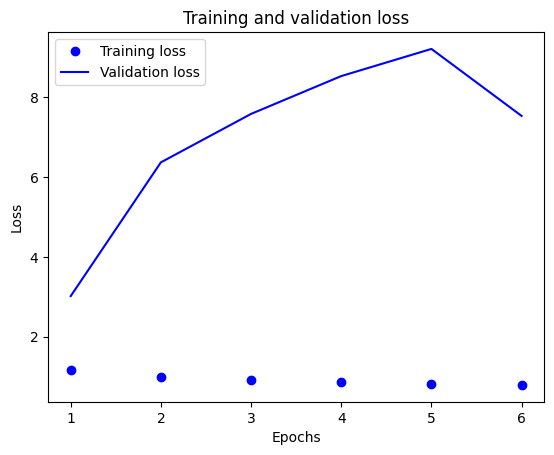

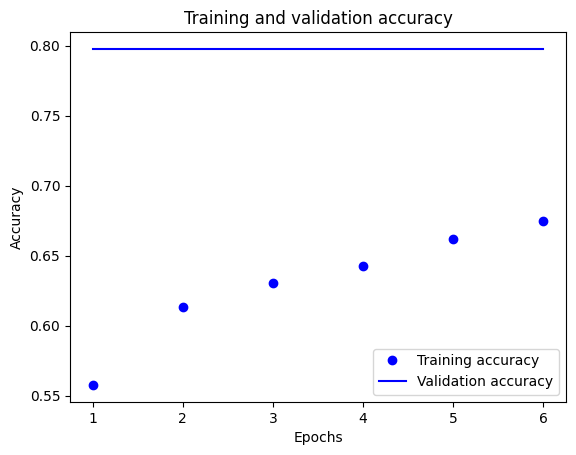

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9542 - loss: 0.6848
Model 1 - Base DamageCNN - Test Accuracy: 0.9542
Model 1 - Base DamageCNN - Test Loss:     0.6848


In [31]:
backend.clear_session()
model1 = Base_DamageCNN()

history1 = model1.fit(
    train_generator,
    steps_per_epoch=len(train_generator), 
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    class_weight=class_weight_dict,     
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1)
    ]
)

plot_history(history1)

test_loss1, test_acc1 = model1.evaluate(test_generator, steps=len(test_generator))
print(f'Model 1 - Base DamageCNN - Test Accuracy: {test_acc1:.4f}')
print(f'Model 1 - Base DamageCNN - Test Loss:     {test_loss1:.4f}')



**Result:** Still 0.00 F1 for minority classes. val_accuracy was still dominated by Intact so early stopping just kept the model that predicted everything as Intact.


## **Class Weights with val_loss Monitoring**

Switching early stopping and LR reduction to monitor val_loss instead of val_accuracy, thinking that loss might give a better signal when class weights are applied.

Epoch 1/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 396s 743ms/step - accuracy: 0.5749 - loss: 1.1095 - val_accuracy: 0.1472 - val_loss: 3.8594 - learning_rate: 1.0000e-04
Epoch 2/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 391s 739ms/step - accuracy: 0.6278 - loss: 0.9635 - val_accuracy: 0.3146 - val_loss: 3.5790 - learning_rate: 1.0000e-04
Epoch 3/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 392s 741ms/step - accuracy: 0.6420 - loss: 0.9054 - val_accuracy: 0.3820 - val_loss: 2.6672 - learning_rate: 1.0000e-04
Epoch 4/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 400s 756ms/step - accuracy: 0.6532 - loss: 0.8626 - val_accuracy: 0.6708 - val_loss: 1.6269 - learning_rate: 1.0000e-04
Epoch 5/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 399s 754ms/step - accuracy: 0.6650 - loss: 0.8318 - val_accuracy: 0.6944 - val_loss: 2.2734 - learning_rate: 1.0000e-04
Epoch 6/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 399s 755ms/step - accuracy: 0.6754 - loss: 0.7913 - val_accuracy: 0.7000 - val_loss: 2.1376 - learning_rate: 1.0000e-04
Epoch 7/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 

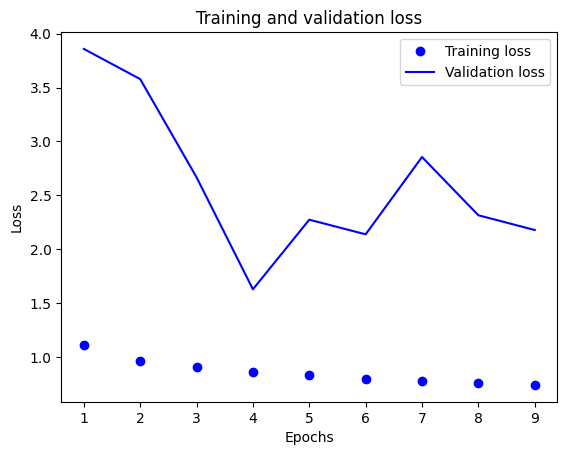

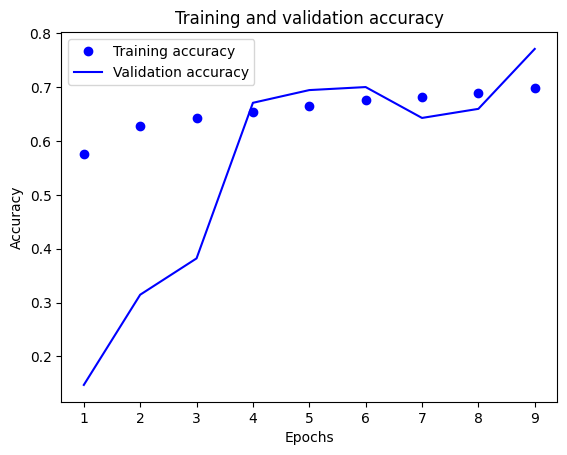

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.8608 - loss: 0.5733
Model 1 - Base DamageCNN - Test Accuracy: 0.8608
Model 1 - Base DamageCNN - Test Loss:     0.5733


AttributeError: module 'h5py' has no attribute 'File'

In [32]:
backend.clear_session()
model1 = Base_DamageCNN()

history1 = model1.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,    
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                          patience=3, verbose=1)
    ]
)

plot_history(history1)

test_loss1, test_acc1 = model1.evaluate(test_generator, steps=len(test_generator))
print(f'Model 1 - Base DamageCNN - Test Accuracy: {test_acc1:.4f}')
print(f'Model 1 - Base DamageCNN - Test Loss:     {test_loss1:.4f}')

model1.save(os.path.join(base_path, 'model1_base_damagecnn.keras'))

In [33]:
test_generator.reset()
preds        = model1.predict(test_generator, steps=len(test_generator), verbose=1)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes[:len(pred_classes)]
class_names  = list(test_generator.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_names))

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step
                    precision    recall  f1-score   support

            Intact       0.95      0.90      0.93      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.86      1049
         macro avg       0.32      0.30      0.31      1049
      weighted avg       0.91      0.86      0.88      1049



**Result:** Still 0.00 F1 for minority classes. The validation loss was still being pulled down by the massive number of Intact images. No improvement.

## **Threshold Adjustment Search**

Before moving to more complex strategies, trying a simple threshold adjustment at inference time. Instead of always picking the class with the highest probability, I lower the confidence threshold for Structural Failure and Major Damage so the model classifies them more aggressively.

Tested thresholds from 0.5 down to 0.05.

In [34]:
# Threshold adjustment - no retraining needed


test_generator.reset()
preds        = model1.predict(test_generator, steps=len(test_generator), verbose=1)
true_classes = test_generator.classes[:len(preds)]
class_names  = list(test_generator.class_indices.keys())

print("Class indices:", test_generator.class_indices)
print("Intact=0, Major_Damage=1, Structural_Failure=2")
print()

thresholds = [0.5, 0.3, 0.2, 0.15, 0.1]

for thresh in thresholds:
    adjusted_preds = []
    for pred in preds:
        intact_prob      = pred[0]
        major_prob       = pred[1]
        structural_prob  = pred[2]

        if structural_prob >= thresh:
            adjusted_preds.append(2)
        elif major_prob >= thresh:
            adjusted_preds.append(1)
        else:
            adjusted_preds.append(0)

    from sklearn.metrics import f1_score
    macro_f1 = f1_score(true_classes, adjusted_preds, average='macro')
    print(f"Threshold {thresh} - Macro F1: {macro_f1:.4f}")
    print(classification_report(true_classes, adjusted_preds, target_names=class_names))
    print("---")

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step
Class indices: {'Intact': 0, 'Major_Damage': 1, 'Structural_Failure': 2}
Intact=0, Major_Damage=1, Structural_Failure=2

Threshold 0.5 - Macro F1: 0.3086
                    precision    recall  f1-score   support

            Intact       0.95      0.90      0.93      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.86      1049
         macro avg       0.32      0.30      0.31      1049
      weighted avg       0.91      0.86      0.88      1049

---
Threshold 0.3 - Macro F1: 0.3009
                    precision    recall  f1-score   support

            Intact       0.95      0.84      0.89      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.01      0.04      0.01        26

          accuracy                           0.80      1049
         macro avg       0.32      0.29    

In [35]:
# Fine-grained threshold search
best_macro_f1  = 0
best_threshold = 0
best_report    = None

for thresh in [0.25, 0.20, 0.18, 0.15, 0.12, 0.10, 0.08, 0.05]:
    adjusted_preds = []
    for pred in preds:
        intact_prob     = pred[0]
        major_prob      = pred[1]
        structural_prob = pred[2]

        if structural_prob >= thresh:
            adjusted_preds.append(2)
        elif major_prob >= thresh:
            adjusted_preds.append(1)
        else:
            adjusted_preds.append(0)

    macro_f1 = f1_score(true_classes, adjusted_preds, average='macro')
    print(f"Threshold {thresh} - Macro F1: {macro_f1:.4f}")

    if macro_f1 > best_macro_f1:
        best_macro_f1  = macro_f1
        best_threshold = thresh
        best_report    = classification_report(
            true_classes, adjusted_preds, target_names=class_names)

print("\n" + "=" * 50)
print(f"Best threshold: {best_threshold}")
print(f"Best macro F1:  {best_macro_f1:.4f}")
print("=" * 50)
print(best_report)

Threshold 0.25 - Macro F1: 0.2962
Threshold 0.2 - Macro F1: 0.2954
Threshold 0.18 - Macro F1: 0.2962
Threshold 0.15 - Macro F1: 0.2920
Threshold 0.12 - Macro F1: 0.2879
Threshold 0.1 - Macro F1: 0.2832
Threshold 0.08 - Macro F1: 0.2759
Threshold 0.05 - Macro F1: 0.2660

Best threshold: 0.25
Best macro F1:  0.2962
                    precision    recall  f1-score   support

            Intact       0.95      0.82      0.88      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.01      0.04      0.01        26

          accuracy                           0.78      1049
         macro avg       0.32      0.29      0.30      1049
      weighted avg       0.90      0.78      0.84      1049



**Result:** Best threshold was 0.25 with Macro F1 of 0.2962, actually worse than the 0.33 baseline. The model's confidence scores for minority classes are so low that even threshold adjustment can't help when the underlying model hasn't learned anything about those classes.

## **Implementing Focal Loss**

Standard crossentropy treats every prediction equally. Focal Loss adds a modulating factor that automatically down-weights easy correct predictions and focuses training on the hard minority class examples the model keeps getting wrong.

Using gamma=2.0 and alpha=0.25 for this initial attempt. This is implemented as a custom TensorFlow loss function.

In [ ]:
# Custom Focal Loss

import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fn(y_true, y_pred):
        y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce       = -y_true * tf.math.log(y_pred)
        weight   = alpha * y_true * tf.pow(1 - y_pred, gamma)
        fl       = weight * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=1))
    return focal_loss_fn

## **Building a Balanced Batch Generator**

Even with Focal Loss, if each batch is still 81% Intact images the model won't learn minority classes well. Building a custom BalancedGenerator that forces exactly 11 images from each class into every batch of 33 total, regardless of how many images each class has on disk.

In [37]:
class BalancedGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=33, target_size=(224, 224)):
        self.batch_size       = batch_size
        self.target_size      = target_size
        self.classes          = ['Intact', 'Major_Damage', 'Structural_Failure']
        self.class_files      = {}
        self.samples_per_class = batch_size // len(self.classes)

        for i, cls in enumerate(self.classes):
            cls_dir = os.path.join(directory, cls)
            files   = [os.path.join(cls_dir, f)
                      for f in os.listdir(cls_dir) if f.endswith('.jpg')]
            self.class_files[i] = files
            print(cls, "files:", len(files))

        self.steps = min(
            len(f) for f in self.class_files.values()) // self.samples_per_class
        print("Steps per epoch:", self.steps)

    def __len__(self):
        return self.steps

    def __getitem__(self, idx):
        from tensorflow.keras.preprocessing.image import load_img, img_to_array
        batch_x = []
        batch_y = []

        for class_idx in range(len(self.classes)):
            files  = self.class_files[class_idx]
            chosen = np.random.choice(files, self.samples_per_class, replace=True)
            for fpath in chosen:
                img            = load_img(fpath, target_size=self.target_size)
                img            = img_to_array(img) / 255.0
                label          = np.zeros(len(self.classes))
                label[class_idx] = 1
                batch_x.append(img)
                batch_y.append(label)

        batch_x = np.array(batch_x)
        batch_y = np.array(batch_y)
        idx_arr = np.arange(len(batch_x))
        np.random.shuffle(idx_arr)
        return batch_x[idx_arr], batch_y[idx_arr]

balanced_gen = BalancedGenerator(train_dir, batch_size=33, target_size=(224, 224))

Intact files: 6542
Major_Damage files: 4284
Structural_Failure files: 6072
Steps per epoch: 389


## **Focal Loss + Balanced Generator (Monitoring val_loss)**

Combining Focal Loss with the Balanced Generator. Early stopping still monitoring val_loss.

In [38]:
def Base_DamageCNN_Focal():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(224, 224, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 308s 785ms/step - accuracy: 0.5322 - loss: 0.2322 - val_accuracy: 0.7978 - val_loss: 0.2468 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 300s 770ms/step - accuracy: 0.5863 - loss: 0.1934 - val_accuracy: 0.7618 - val_loss: 0.5716 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 300s 770ms/step - accuracy: 0.5939 - loss: 0.1747 - val_accuracy: 0.7978 - val_loss: 0.7315 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.6051 - loss: 0.1653
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
389/389 ━━━━━━━━━━━━━━━━━━━━ 300s 771ms/step - accuracy: 0.6052 - loss: 0.1627 - val_accuracy: 0.7966 - val_loss: 0.7295 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 301s 774ms/step - accuracy: 0.6164 - loss: 0.1545 - val_accuracy: 0.7978 - val_loss: 0.8186 - learning_rate: 5.0000e-05
Epoch 6/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 301s 77

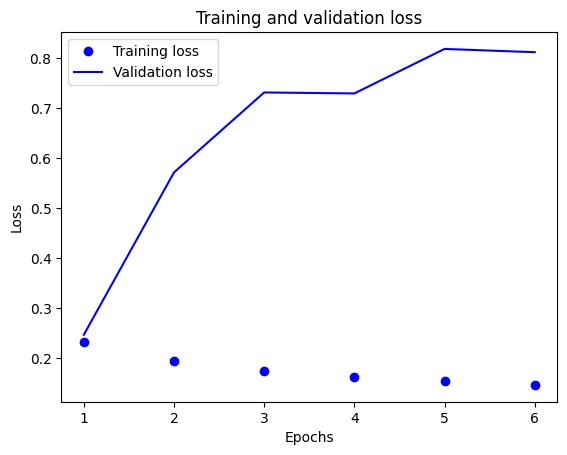

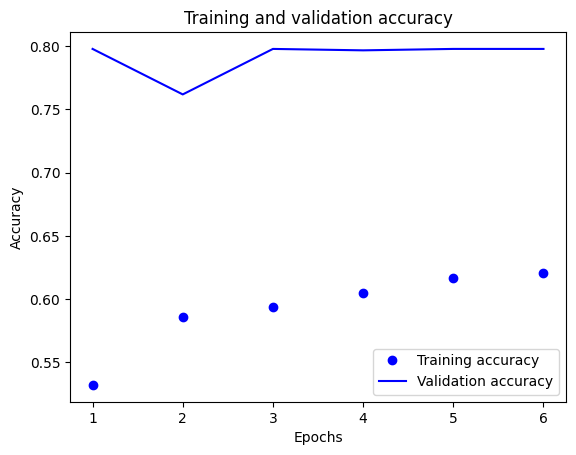

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.9542 - loss: 0.1021
Focal Loss + Balanced - Test Accuracy: 0.9542
Focal Loss + Balanced - Test Loss:     0.1021


In [39]:
backend.clear_session()
model1_focal = Base_DamageCNN_Focal()

history_focal = model1_focal.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]
)

plot_history(history_focal)

test_loss_focal, test_acc_focal = model1_focal.evaluate(
    test_generator, steps=len(test_generator))
print(f'Focal Loss + Balanced - Test Accuracy: {test_acc_focal:.4f}')
print(f'Focal Loss + Balanced - Test Loss:     {test_loss_focal:.4f}')

In [40]:
test_generator.reset()
preds_focal        = model1_focal.predict(
    test_generator, steps=len(test_generator), verbose=1)
pred_classes_focal = np.argmax(preds_focal, axis=1)
true_classes_focal = test_generator.classes[:len(pred_classes_focal)]

print(classification_report(true_classes_focal, pred_classes_focal,
                             target_names=class_names))

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step
                    precision    recall  f1-score   support

            Intact       0.95      1.00      0.98      1001
      Major_Damage       0.00      0.00      0.00        22
Structural_Failure       0.00      0.00      0.00        26

          accuracy                           0.95      1049
         macro avg       0.32      0.33      0.33      1049
      weighted avg       0.91      0.95      0.93      1049



**Result:** Test accuracy 0.9542, but classification report still shows 0.00 F1 for both minority classes. The validation generator was still unbalanced so val_loss was still dominated by Intact. The model never got credit for improving on minority classes.

## **Adding Macro F1 as a Training Metric**

The root issue is that val_accuracy and val_loss don't reflect minority class performance at all. I need a metric that rewards the model specifically for improving across all three classes equally.

Implementing a custom Macro F1 metric in TensorFlow/Keras so it can be monitored during training and used to drive early stopping and LR reduction.

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def macro_f1(y_true, y_pred):
    y_true   = tf.cast(y_true, tf.float32)   
    y_pred   = tf.cast(tf.round(y_pred), tf.float32)
    f1_scores = []

    for i in range(3):
        tp = K.sum(y_true[:, i] * y_pred[:, i])
        fp = K.sum((1 - y_true[:, i]) * y_pred[:, i])
        fn = K.sum(y_true[:, i] * (1 - y_pred[:, i]))

        precision = tp / (tp + fp + K.epsilon())
        recall    = tp / (tp + fn + K.epsilon())
        f1        = 2 * precision * recall / (precision + recall + K.epsilon())
        f1_scores.append(f1)

    return tf.reduce_mean(tf.stack(f1_scores))

## **Focal Loss + Balanced Generator + Macro F1 Monitoring**

Now switching early stopping and ReduceLROnPlateau to monitor val_macro_f1 instead of val_loss. This means the model only gets rewarded and training only continues, if it improves on all three classes, not just Intact.

In [ ]:
def Base_DamageCNN_F1():
    backend.clear_session()
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=(224, 224, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy', macro_f1]  
    )
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,923 (1.75 MB)

 Trainable params: 456,451 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 306s 779ms/step - accuracy: 0.5063 - loss: 0.2576 - macro_f1: 0.4738 - val_accuracy: 0.5764 - val_loss: 0.1492 - val_macro_f1: 0.2814 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 303s 778ms/step - accuracy: 0.5715 - loss: 0.2105 - macro_f1: 0.5438 - val_accuracy: 0.7978 - val_loss: 0.3795 - val_macro_f1: 0.2951 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 302s 776ms/step - accuracy: 0.5786 - loss: 0.1909 - macro_f1: 0.5523 - val_accuracy: 0.7910 - val_loss: 0.4187 - val_macro_f1: 0.2920 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 301s 775ms/step - accuracy: 0.6017 - loss: 0.1730 - macro_f1: 0.5708 - val_accuracy: 0.7978 - val_loss: 0.4585 - val_macro_f1: 0.2945 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 304s 780ms/step - accuracy: 0.6131 - loss: 0.1600 - macro_f1: 0.5826 - val_accuracy: 0.7978 - val_loss: 0.6359 - val_macro_f1: 0.2953 - learning_rate: 1

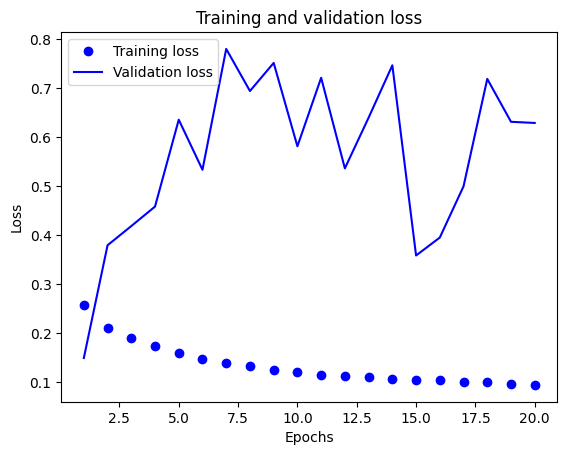

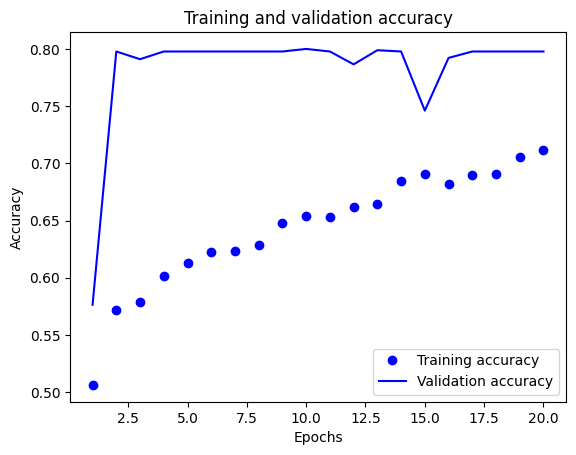

In [ ]:
backend.clear_session()
model1_f1 = Base_DamageCNN_F1()
model1_f1.summary()

history_f1 = model1_f1.fit(
    balanced_gen,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_macro_f1',     
                      patience=5,
                      restore_best_weights=True,
                      mode='max'),                 
        ReduceLROnPlateau(monitor='val_macro_f1',
                          factor=0.5,
                          patience=3,
                          verbose=1,
                          mode='max')
    ]
)

plot_history(history_f1)

Training runs for 20 epochs before early stopping triggers. The validation Macro F1 reaches around 0.34